<a href="https://colab.research.google.com/github/AkshitaNipane/Machine-Learning-TAE/blob/main/MODEL_3_ML_TAE(DecisionTree).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAME:AKSHITA NIPANE(CS23019)MODEL 3:To build and evaluate a Decision Tree model for predicting Customer Satisfaction and analyze model performance.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
df = pd.read_csv('/content/customer_feedback_satisfaction.csv')
df.head()

,CustomerID,Age,Gender,Country,Income,ProductQuality,ServiceQuality,PurchaseFrequency,FeedbackScore,LoyaltyLevel,SatisfactionScore
0,1,56,Male,UK,83094,5,8,5,Low,Bronze,100.0
1,2,69,Male,UK,86860,10,2,8,Medium,Gold,100.0
2,3,46,Female,USA,60173,8,10,18,Medium,Silver,100.0
3,4,32,Female,UK,73884,7,10,16,Low,Gold,100.0
4,5,60,Male,UK,97546,6,4,13,Low,Bronze,82.0


In [6]:
print(df.shape)
print(df.info())
print(df.describe())

(38444, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38444 entries, 0 to 38443
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         38444 non-null  int64  
 1   Age                38444 non-null  int64  
 2   Gender             38444 non-null  object 
 3   Country            38444 non-null  object 
 4   Income             38444 non-null  int64  
 5   ProductQuality     38444 non-null  int64  
 6   ServiceQuality     38444 non-null  int64  
 7   PurchaseFrequency  38444 non-null  int64  
 8   FeedbackScore      38444 non-null  object 
 9   LoyaltyLevel       38444 non-null  object 
 10  SatisfactionScore  38444 non-null  float64
dtypes: float64(1), int64(6), object(4)
memory usage: 3.2+ MB
None
         CustomerID           Age         Income  ProductQuality  \
count  38444.000000  38444.000000   38444.000000    38444.000000   
mean   19222.500000     43.496853   75076.619238    

In [7]:
# Drop unnecessary column
df = df.drop('CustomerID', axis=1)
# Convert categorical to numeric
df = pd.get_dummies(df, drop_first=True)

df.head()

,Age,Income,ProductQuality,ServiceQuality,PurchaseFrequency,SatisfactionScore,Gender_Male,Country_France,Country_Germany,Country_UK,Country_USA,FeedbackScore_Low,FeedbackScore_Medium,LoyaltyLevel_Gold,LoyaltyLevel_Silver
0,56,83094,5,8,5,100.0,True,False,False,True,False,True,False,False,False
1,69,86860,10,2,8,100.0,True,False,False,True,False,False,True,True,False
2,46,60173,8,10,18,100.0,False,False,False,False,True,False,True,False,True
3,32,73884,7,10,16,100.0,False,False,False,True,False,True,False,True,False
4,60,97546,6,4,13,82.0,True,False,False,True,False,True,False,False,False


In [8]:
# Convert satisfaction score into label (0 = low, 1 = high)
df['SatisfactionLabel'] = (df['SatisfactionScore'] > df['SatisfactionScore'].mean()).astype(int)

df.head()

,Age,Income,ProductQuality,ServiceQuality,PurchaseFrequency,SatisfactionScore,Gender_Male,Country_France,Country_Germany,Country_UK,Country_USA,FeedbackScore_Low,FeedbackScore_Medium,LoyaltyLevel_Gold,LoyaltyLevel_Silver,SatisfactionLabel
0,56,83094,5,8,5,100.0,True,False,False,True,False,True,False,False,False,1
1,69,86860,10,2,8,100.0,True,False,False,True,False,False,True,True,False,1
2,46,60173,8,10,18,100.0,False,False,False,False,True,False,True,False,True,1
3,32,73884,7,10,16,100.0,False,False,False,True,False,True,False,True,False,1
4,60,97546,6,4,13,82.0,True,False,False,True,False,True,False,False,False,0


In [9]:
X = df.drop(['SatisfactionScore', 'SatisfactionLabel'], axis=1)
y = df['SatisfactionLabel']

print(X)
print(y)

       Age  Income  ProductQuality  ServiceQuality  PurchaseFrequency  \
0       56   83094               5               8                  5   
1       69   86860              10               2                  8   
2       46   60173               8              10                 18   
3       32   73884               7              10                 16   
4       60   97546               6               4                 13   
...    ...     ...             ...             ...                ...   
38439   55   80880               6               3                 14   
38440   44   42845               5              10                  1   
38441   43   71433               7               9                  7   
38442   28  105587               7               5                 16   
38443   64  105379               2               2                  8   

       Gender_Male  Country_France  Country_Germany  Country_UK  Country_USA  \
0             True           False         

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train.shape)
print(X_test.shape)

(26910, 14)
(11534, 14)


In [11]:
model = DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)

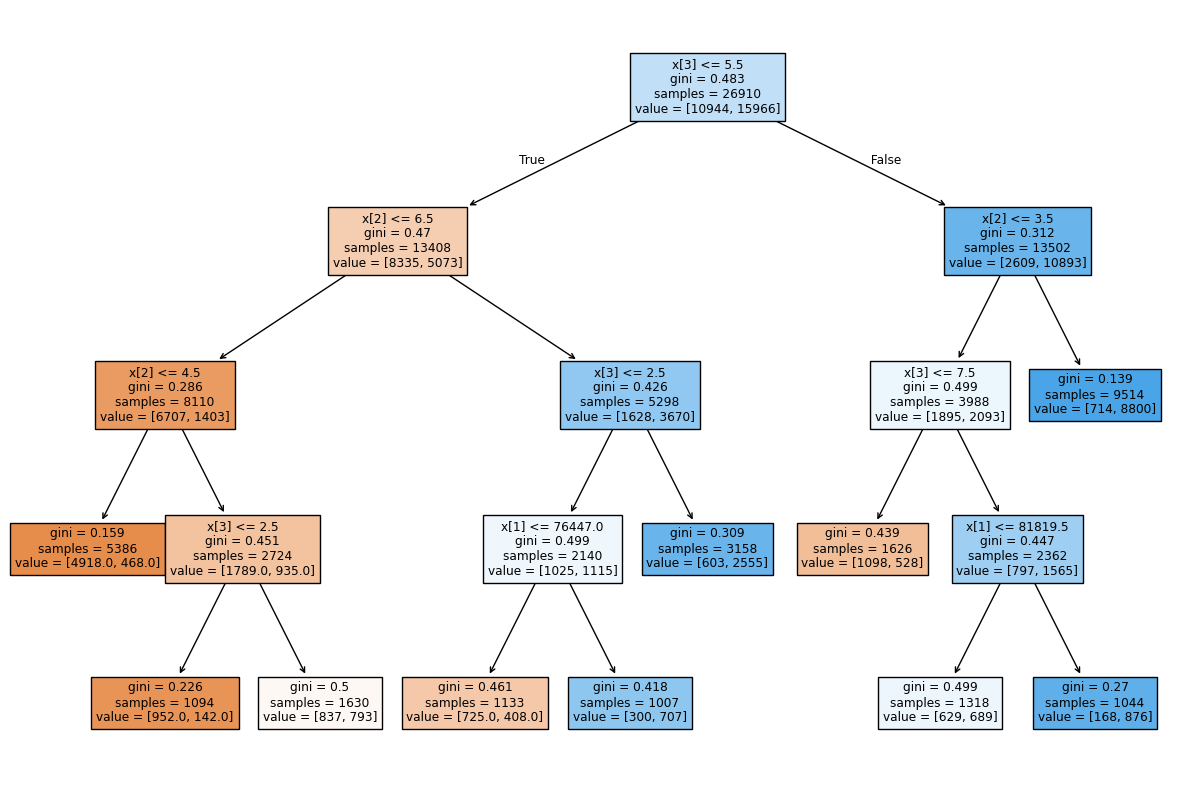

In [12]:
from sklearn import tree

plt.figure(figsize=(15,10))
tree.plot_tree(model, filled=True)
plt.show()

In [13]:
y_pred = model.predict(X_test)

print(y_pred)

[0 1 1 ... 1 0 0]


In [14]:
print(confusion_matrix(y_pred, y_test))

[[3675 1025]
 [1042 5792]]


In [15]:
accuracy = accuracy_score(y_pred, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.8207907057395526


In [16]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.78      0.78      0.78      4700
           1       0.85      0.85      0.85      6834

    accuracy                           0.82     11534
   macro avg       0.81      0.81      0.81     11534
weighted avg       0.82      0.82      0.82     11534



In [18]:
from sklearn.ensemble import ExtraTreesClassifier

#Train Extra Trees (70:30 & 80:20)
for split in [0.3, 0.2]:
    print(f"\n===== Train-Test Split {(1-split)*100:.0f}:{split*100:.0f} =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split, random_state=42
    )

    # 🔹 Extra Trees Model
    model = ExtraTreesClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


===== Train-Test Split 70:30 =====
Accuracy: 0.8596323911912607

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.81      0.83      4717
           1       0.87      0.89      0.88      6817

    accuracy                           0.86     11534
   macro avg       0.86      0.85      0.85     11534
weighted avg       0.86      0.86      0.86     11534


Confusion Matrix:
 [[3828  889]
 [ 730 6087]]

===== Train-Test Split 80:20 =====
Accuracy: 0.856678371699831

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.80      0.82      3121
           1       0.87      0.89      0.88      4568

    accuracy                           0.86      7689
   macro avg       0.85      0.85      0.85      7689
weighted avg       0.86      0.86      0.86      7689


Confusion Matrix:
 [[2505  616]
 [ 486 4082]]
